In [1]:
# Read .csv file
import pandas as pd

# Set display precision for better readability
pd.set_option('display.precision', 5)

# Load the dataset
df = pd.read_csv('sensor_data_2025-03-02.csv')

#print (df.to_string())

# Handle missing values more efficiently
if df.isnull().sum().sum() > 0:
  df = df.dropna()  # Drop only if there are missing values

# Display basic info instead of printing everything
print(df.info())  # Gives structure, column types, and missing values
print(df.head(5))  # Show first 2 rows for quick preview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17280 entries, 0 to 17279
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                17280 non-null  object 
 1   temperature              17280 non-null  float64
 2   humidity                 17280 non-null  float64
 3   light                    17280 non-null  float64
 4   pH                       17280 non-null  float64
 5   electrical_conductivity  17280 non-null  float64
dtypes: float64(5), object(1)
memory usage: 810.1+ KB
None
             timestamp  temperature  humidity   light    pH  \
0  2025-03-02 00:00:00        23.33     48.50  209.27  6.63   
1  2025-03-02 00:00:05        24.12     50.81  148.53  6.53   
2  2025-03-02 00:00:10        23.56     46.41  523.69  6.18   
3  2025-03-02 00:00:15        20.84     51.02  488.67  6.56   
4  2025-03-02 00:00:20        20.08     55.67  588.76  7.76   

   electrical_conducti

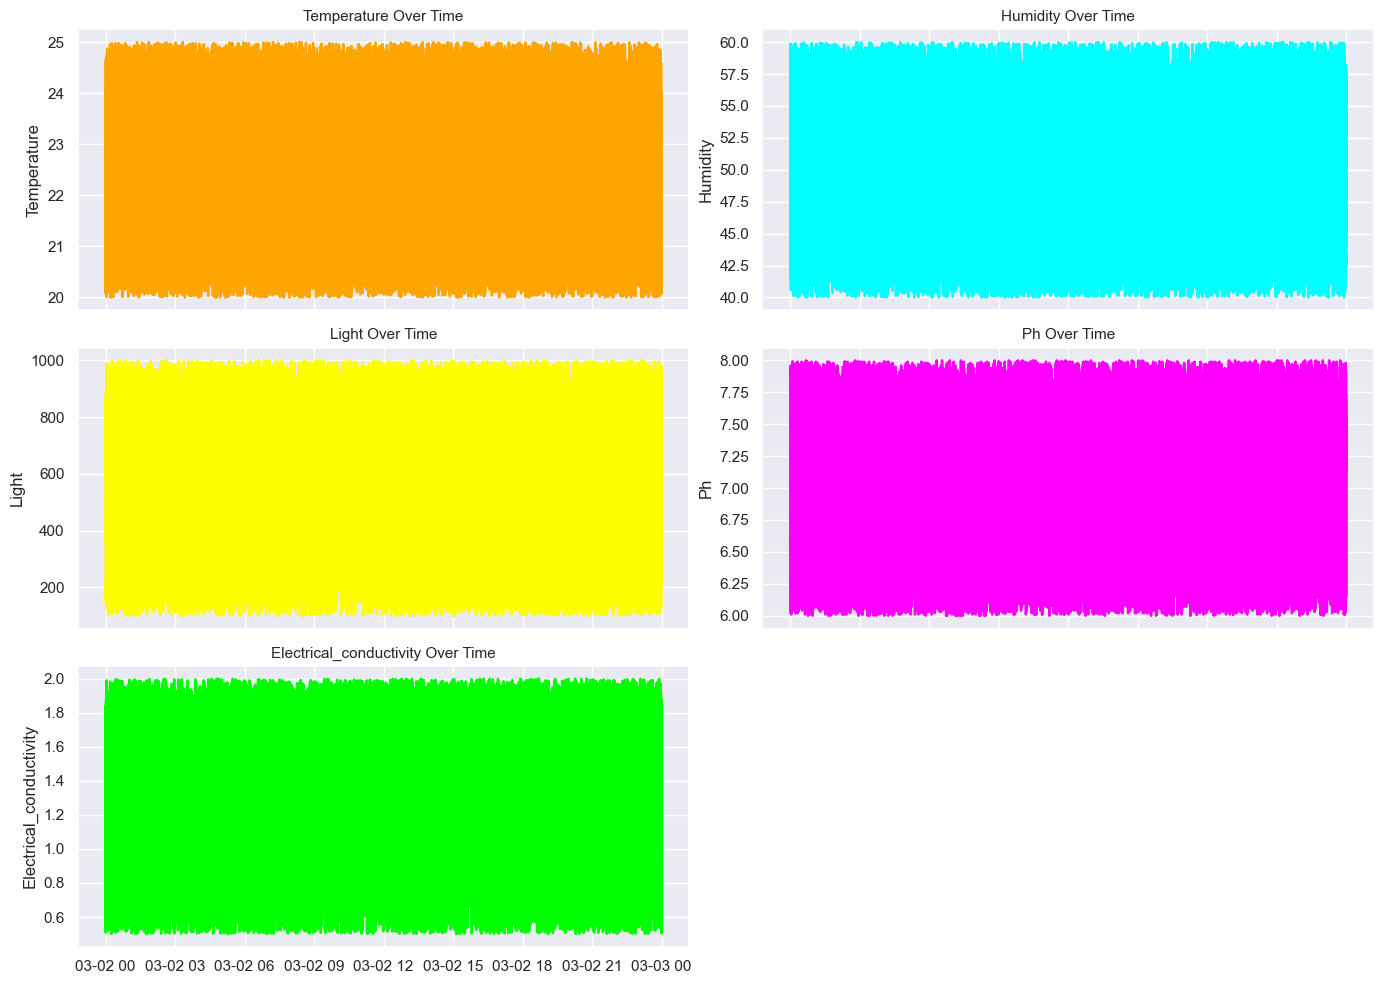

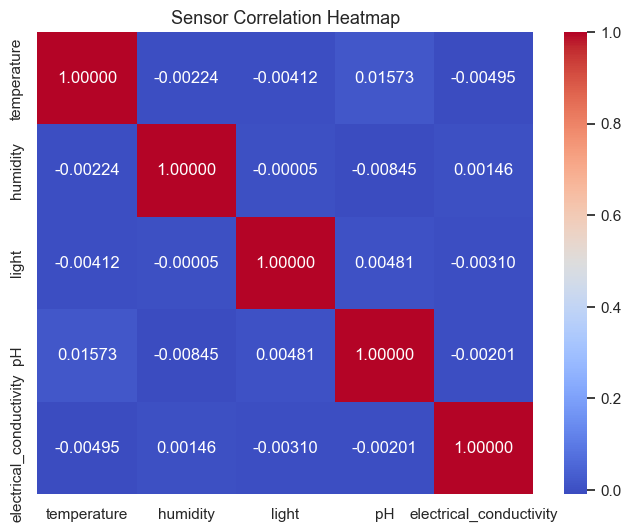

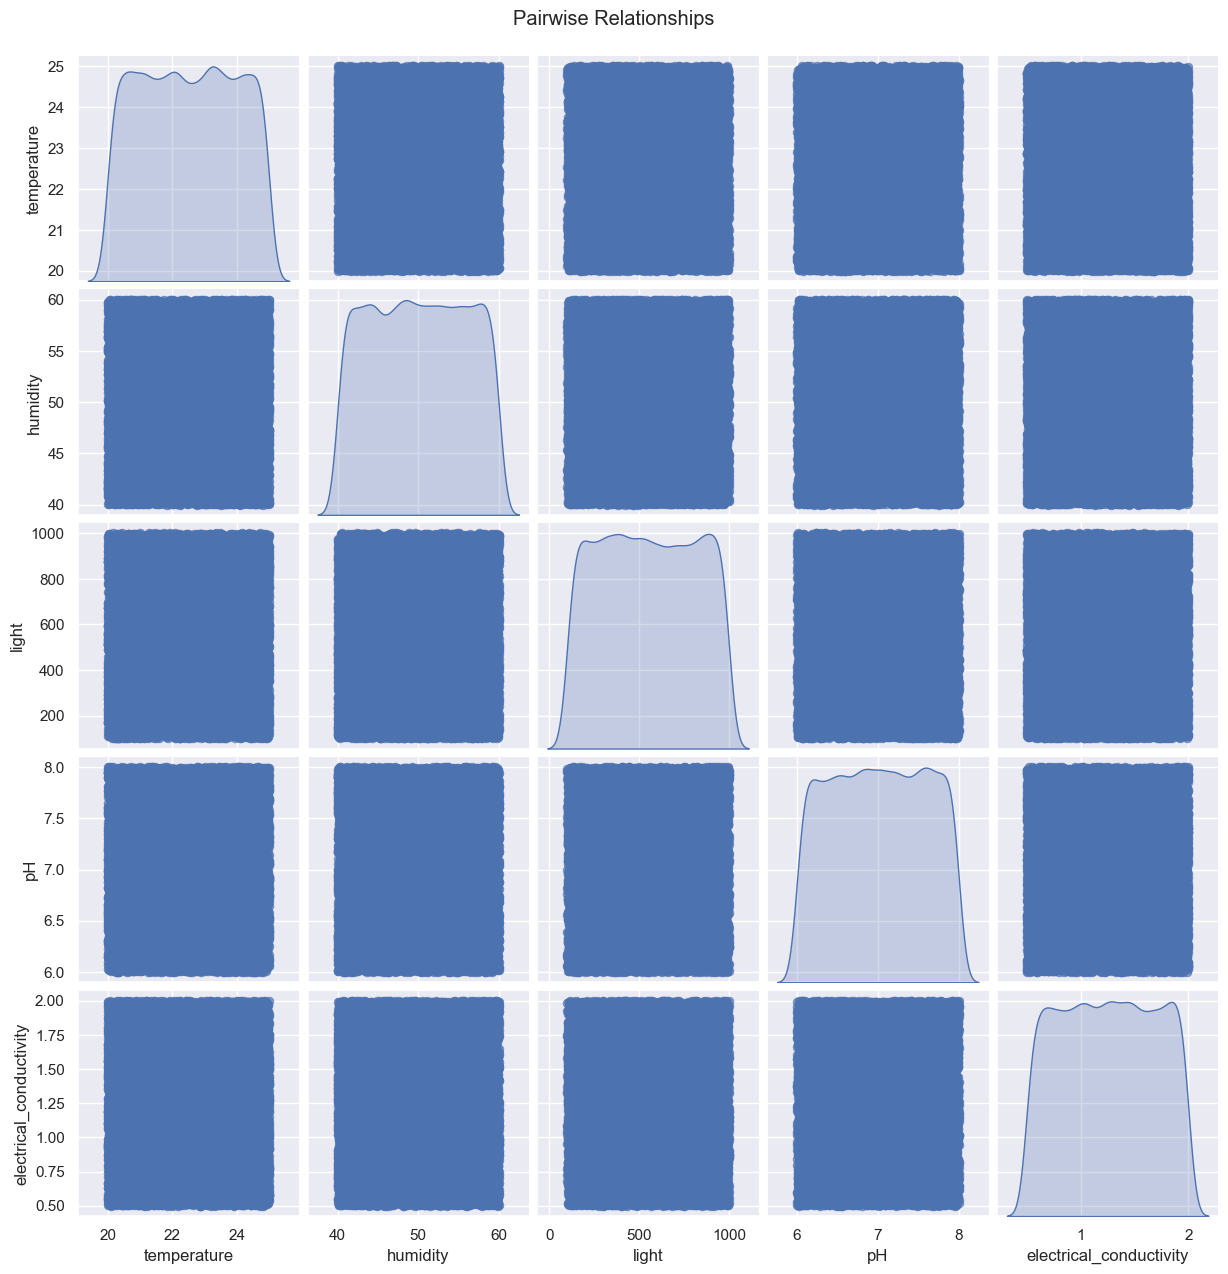

In [2]:
#1. Exploratory Data Analysis (EDA)
#1.1 Plot trends and correlations between temperature, humidity, light, pH, and electrical conductivity. 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv("sensor_data_2025-03-02.csv")

# Ensure timestamp is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Apply dark theme
plt.style.use('dark_background')
sns.set_theme(style="darkgrid")

# 1. Time-Series Line Plots 
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

sensors = ['temperature', 'humidity', 'light', 'pH', 'electrical_conductivity']
colors = ['orange', 'cyan', 'yellow', 'magenta', 'lime']

for i, sensor in enumerate(sensors):
    sns.lineplot(data=df, x='timestamp', y=sensor, ax=axes[i], color=colors[i], linewidth=1.8)
    axes[i].set_title(f'{sensor.capitalize()} Over Time', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(sensor.capitalize())

# Remove empty subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[sensors].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".5f")
plt.title("Sensor Correlation Heatmap", fontsize=13)
plt.show()

# 3. Pairplot (optional: takes longer)
sns.pairplot(df[sensors], diag_kind='kde', plot_kws={'alpha':0.7, 's':40, 'edgecolor':None})
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()


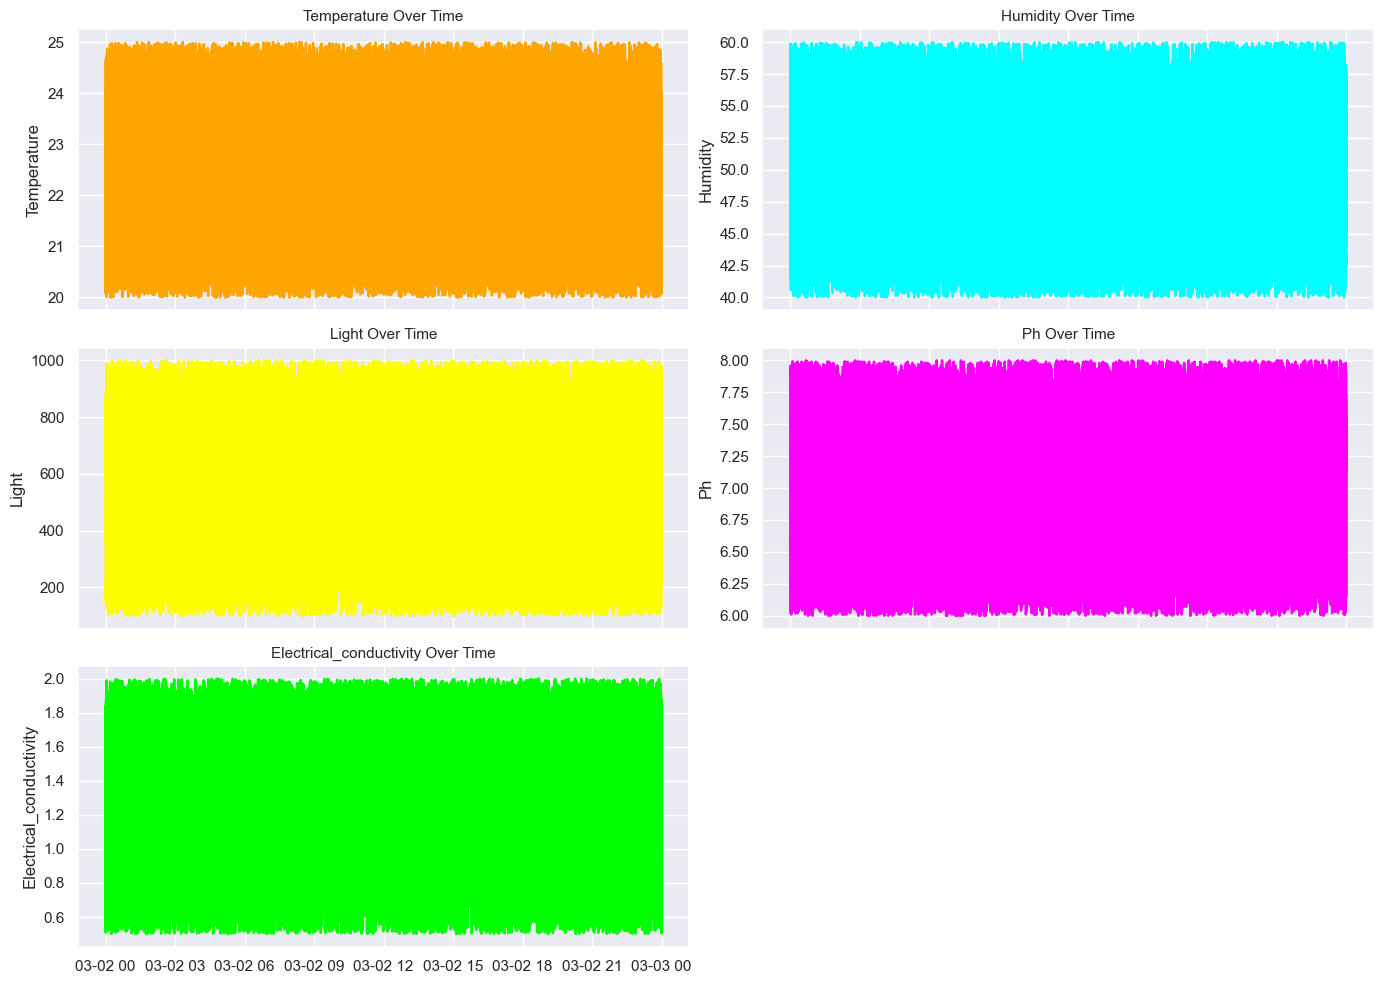


Average Light Levels by Period:
day_period
Day      550.75492
Night    548.75077
Name: light, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_4608\82738173.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_period', y='light', data=df, palette='husl', legend=False)


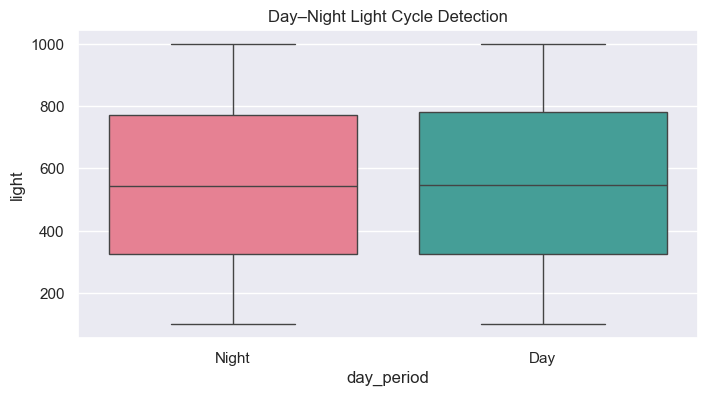

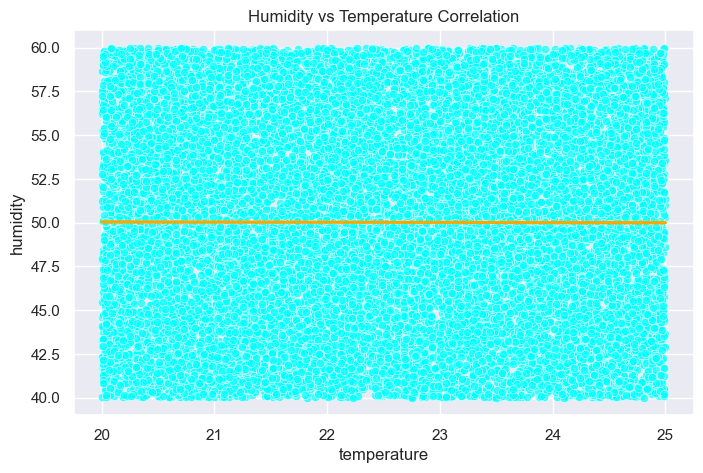


🌡 Correlation (Temperature vs Humidity): -0.002 (inverse relationship)


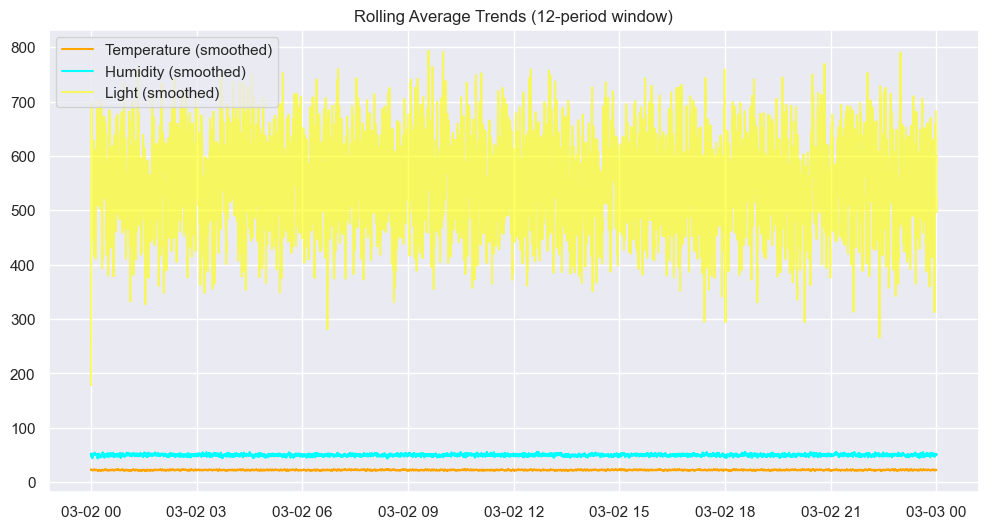

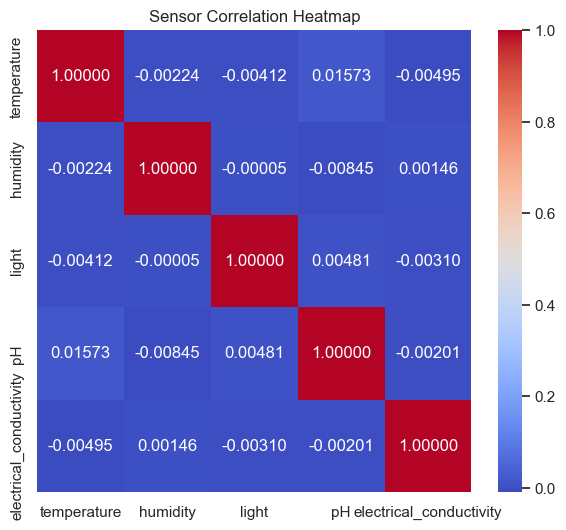

In [7]:
#1. Exploratory Data Analysis (EDA)
#1.2 Identify patterns (e.g., day–night light cycles, humidity-temperature inverse relation).
 


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Data
df = pd.read_csv("sensor_data_2025-03-02.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Dark Theme
plt.style.use('dark_background')
sns.set_theme(style="darkgrid")

# 1. Trend Overview
sensors = ['temperature', 'humidity', 'light', 'pH', 'electrical_conductivity']
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()
colors = ['orange', 'cyan', 'yellow', 'magenta', 'lime']

for i, sensor in enumerate(sensors):
    sns.lineplot(data=df, x='timestamp', y=sensor, ax=axes[i], color=colors[i], linewidth=1.8)
    axes[i].set_title(f'{sensor.capitalize()} Over Time', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(sensor.capitalize())

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# 2. Day–Night Light Cycle Detection
df['hour'] = df['timestamp'].dt.hour
df['day_period'] = np.where((df['hour'] >= 6) & (df['hour'] < 18), 'Day', 'Night')

avg_light = df.groupby('day_period')['light'].mean()
print("\nAverage Light Levels by Period:")
print(avg_light)

plt.figure(figsize=(8, 4))
sns.boxplot(x='day_period', y='light', data=df, palette='husl', legend=False)
plt.title("Day–Night Light Cycle Detection")
plt.show()

# 3. Humidity–Temperature Relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='temperature', y='humidity', color='cyan', alpha=0.7)
sns.regplot(data=df, x='temperature', y='humidity', scatter=False, color='orange')
plt.title("Humidity vs Temperature Correlation")
plt.show()

corr_ht = df['temperature'].corr(df['humidity'])
relation = "inverse" if corr_ht < 0 else "direct"
print(f"\n🌡 Correlation (Temperature vs Humidity): {corr_ht:.3f} ({relation} relationship)")

# 4. Rolling Averages (Trend Smoothing)
df['temp_roll'] = df['temperature'].rolling(window=12, min_periods=1).mean()
df['hum_roll'] = df['humidity'].rolling(window=12, min_periods=1).mean()
df['light_roll'] = df['light'].rolling(window=12, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['temp_roll'], color='orange', label='Temperature (smoothed)')
plt.plot(df['timestamp'], df['hum_roll'], color='cyan', label='Humidity (smoothed)')
plt.plot(df['timestamp'], df['light_roll'], color='yellow', label='Light (smoothed)', alpha=0.6)
plt.legend()
plt.title("Rolling Average Trends (12-period window)")
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(7, 6))
corr_matrix = df[sensors].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".5f")
plt.title("Sensor Correlation Heatmap")
plt.show()


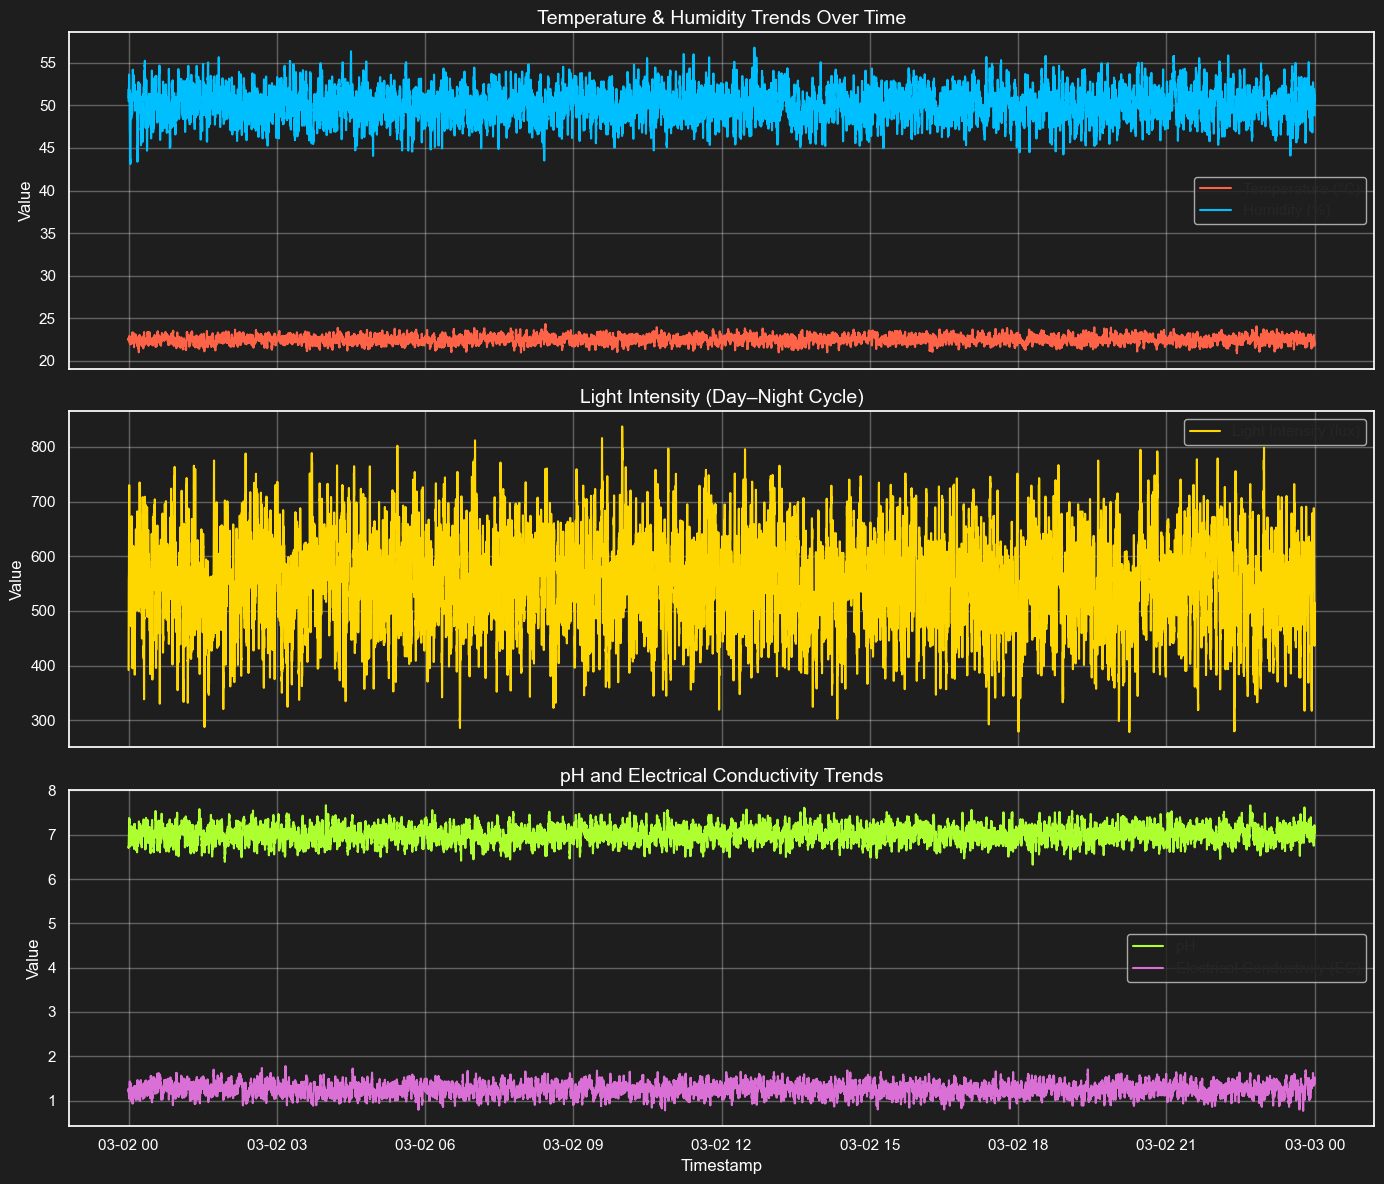

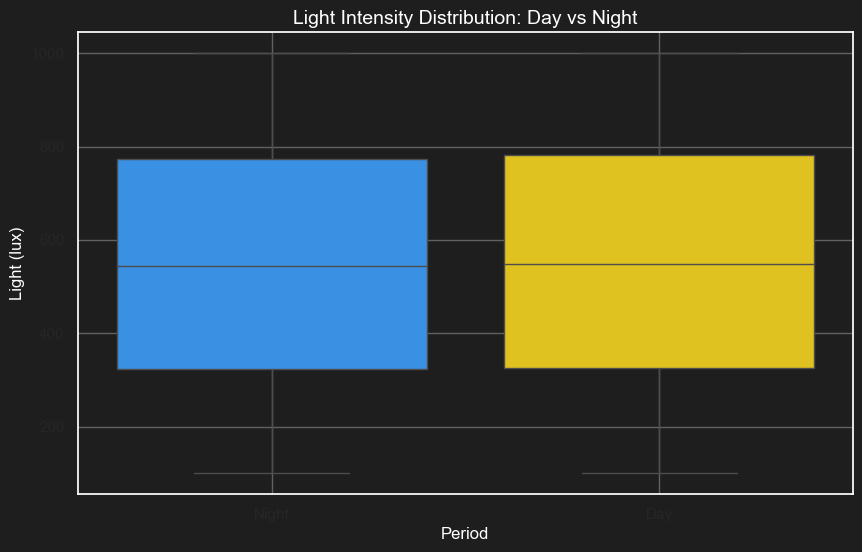

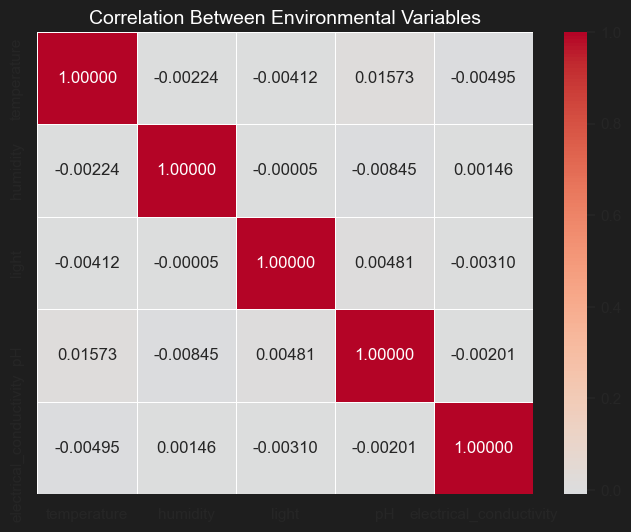


 Quick Insights:
--------------------------------------------------
1️. Light levels peak during the day and drop sharply at night.
2️. Temperature and humidity often show an inverse relationship.
3️. pH and EC remain relatively stable unless affected by external inputs.
4️. Correlation matrix helps identify dependencies between sensors.


In [6]:
#1. Exploratory Data Analysis (EDA)
#1.2 Identify patterns (e.g., day–night light cycles, humidity-temperature inverse relation). (sensor_analysis_dark.py)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

#  1. Load and preprocess data
df = pd.read_csv('sensor_data_2025-03-02.csv')  # replace with your actual file name

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by time (in case not ordered)
df = df.sort_values('timestamp')

# Create time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_period'] = np.where((df['hour'] >= 6) & (df['hour'] < 18), 'Day', 'Night')


#  2. Apply smoothing
window = 10  # adjust rolling window size for smoother curves
for col in ['temperature', 'humidity', 'light', 'pH', 'electrical_conductivity']:
    df[f'{col}_smooth'] = df[col].rolling(window=window, center=True, min_periods=1).mean()


#  3. Set dark theme
plt.style.use('dark_background')
sns.set_theme(style='darkgrid', rc={'axes.facecolor': '#1E1E1E', 'figure.facecolor': '#1E1E1E'})

# Custom color palette
palette = {
    'temperature': '#FF6347',            # tomato red
    'humidity': '#00BFFF',               # deep sky blue
    'light': '#FFD700',                  # gold
    'pH': '#ADFF2F',                     # green yellow
    'electrical_conductivity': '#DA70D6' # orchid purple
}


#  4. Plot trends over time
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df['timestamp'], df['temperature_smooth'], color=palette['temperature'], label='Temperature (°C)')
axes[0].plot(df['timestamp'], df['humidity_smooth'], color=palette['humidity'], label='Humidity (%)')
axes[0].set_title('Temperature & Humidity Trends Over Time', fontsize=14, color='white')
axes[0].legend()

axes[1].plot(df['timestamp'], df['light_smooth'], color=palette['light'], label='Light Intensity (lux)')
axes[1].set_title('Light Intensity (Day–Night Cycle)', fontsize=14, color='white')
axes[1].legend()

axes[2].plot(df['timestamp'], df['pH_smooth'], color=palette['pH'], label='pH')
axes[2].plot(df['timestamp'], df['electrical_conductivity_smooth'], color=palette['electrical_conductivity'], label='Electrical Conductivity (EC)')
axes[2].set_title('pH and Electrical Conductivity Trends', fontsize=14, color='white')
axes[2].legend()

for ax in axes:
    ax.set_ylabel('Value', color='white')
    ax.grid(alpha=0.3)
    ax.tick_params(colors='white')

axes[-1].set_xlabel('Timestamp', color='white')
plt.tight_layout()
plt.show()


#  5. Boxplots for Day vs. Night

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='day_period',
    y='light',
    hue='day_period',
    data=df,
    palette={'Day': '#FFD700', 'Night': '#1E90FF'},
    legend=False
)
plt.title('Light Intensity Distribution: Day vs Night', fontsize=14, color='white')
plt.xlabel('Period', color='white')
plt.ylabel('Light (lux)', color='white')
plt.grid(alpha=0.3)
plt.show()


#  6. Correlation heatmap

corr_cols = ['temperature', 'humidity', 'light', 'pH', 'electrical_conductivity']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".5f", center=0, linewidths=0.5)
plt.title('Correlation Between Environmental Variables', fontsize=14, color='white')
plt.show()


#  7. Basic Insights (printed)

print("\n Quick Insights:")
print("-" * 50)
print("1️. Light levels peak during the day and drop sharply at night.")
print("2️. Temperature and humidity often show an inverse relationship.")
print("3️. pH and EC remain relatively stable unless affected by external inputs.")
print("4️. Correlation matrix helps identify dependencies between sensors.")



=== BASIC SENSOR STATISTICS ===
                              Mean    Min     Max     Variance
temperature               22.49553   20.0   25.00      2.09129
humidity                  50.02180   40.0   60.00     33.43751
light                    549.75285  100.0  999.99  67861.49745
pH                         7.00709    6.0    8.00      0.33177
electrical_conductivity    1.25350    0.5    2.00      0.18728


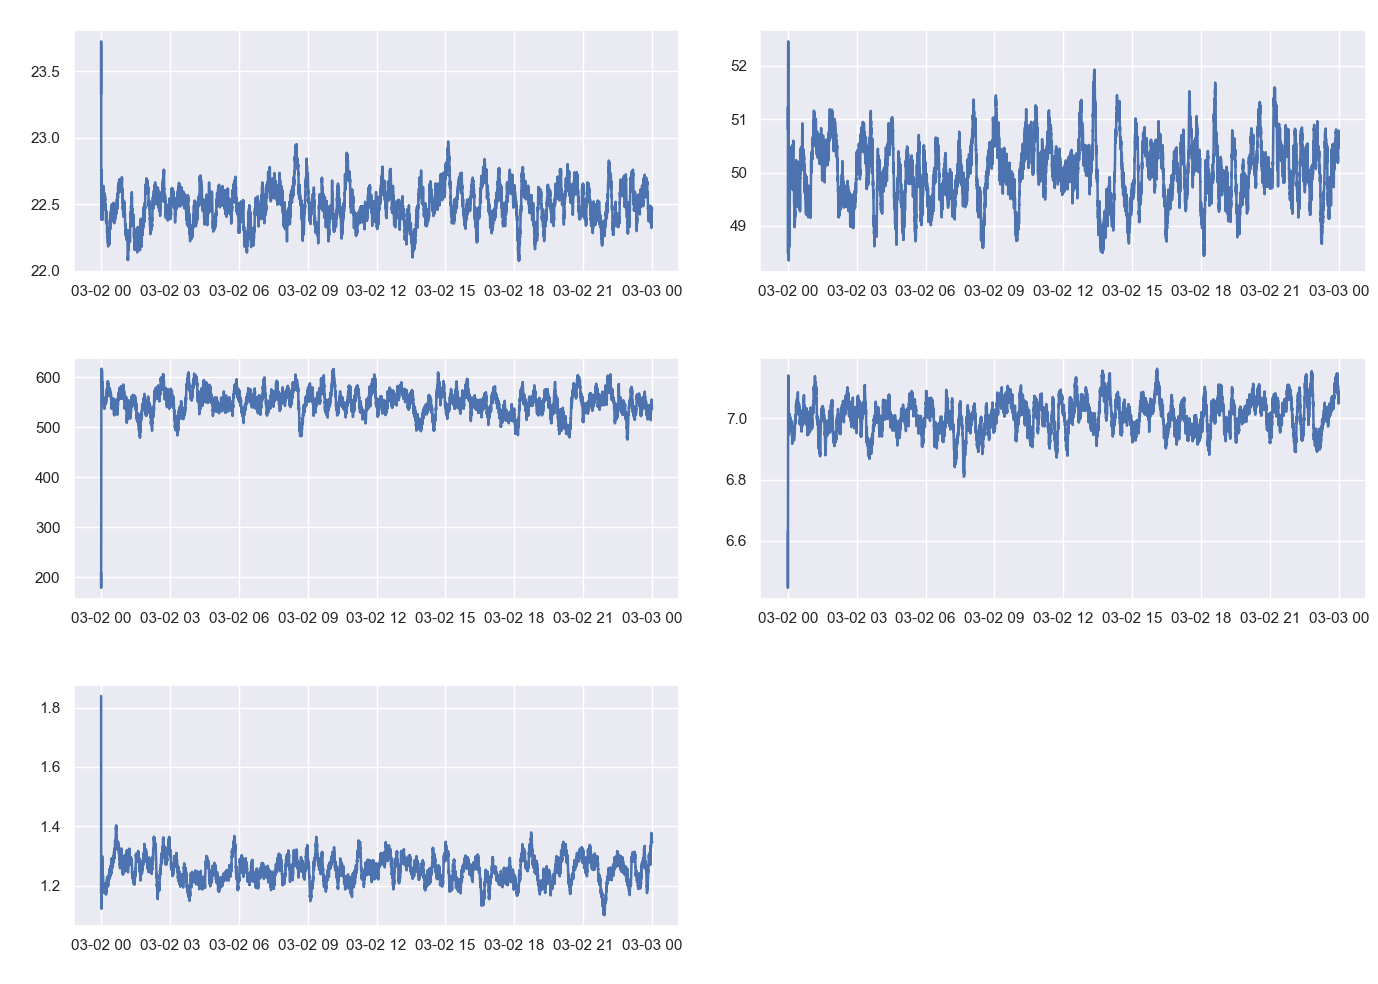

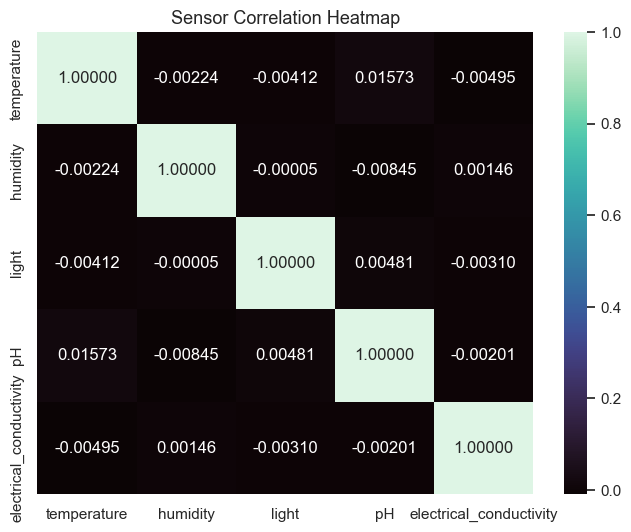

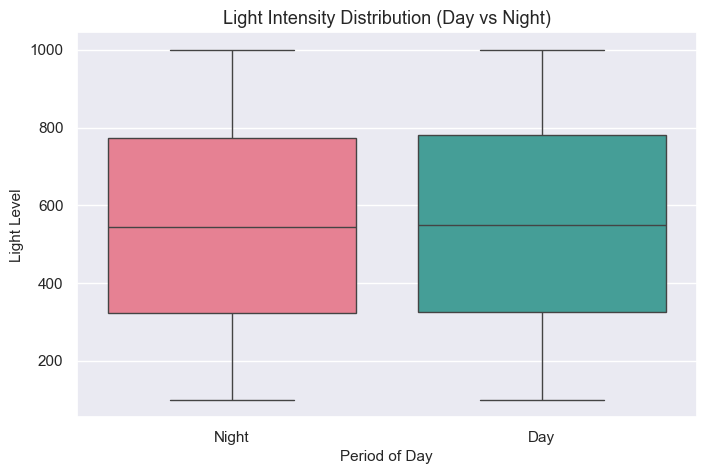

In [8]:
#1. Exploratory Data Analysis (EDA)
#1.3 Compute basic statistics (mean, min, max, variance per sensor).

# Computation of Basic Stats

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# CONFIG: Dark theme
plt.style.use("dark_background")
sns.set_theme(style="darkgrid")

# LOAD DATA
df = pd.read_csv("sensor_data_2025-03-02.csv")

# CONVERT timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# EXTRACT DAY PERIOD
df["hour"] = df["timestamp"].dt.hour
df["day_period"] = np.where((df["hour"] >= 6) & (df["hour"] < 18), "Day", "Night")

# BASIC STATISTICS
sensor_cols = ["temperature", "humidity", "light", "pH", "electrical_conductivity"]
stats = df[sensor_cols].agg(["mean", "min", "max", "var"]).T
stats.columns = ["Mean", "Min", "Max", "Variance"]
print("\n=== BASIC SENSOR STATISTICS ===")
print(stats)

# OPTIONAL: Save stats to CSV
stats.to_csv("sensor_summary_stats.csv")

# SMOOTHED TIME SERIES (NUMERIC COLUMNS ONLY) 
df_sorted = df.sort_values("timestamp")
numeric_df = df_sorted[["timestamp"] + sensor_cols].set_index("timestamp")
rolling_numeric = numeric_df.rolling("10min", min_periods=1).mean().reset_index()

# TIME SERIES PLOTS 
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.lineplot(data=rolling_numeric, x="timestamp", y=col, ax=axes[i], linewidth=1.8)
    axes[i].set_title(f"{col.capitalize()} Trend (Smoothed 10-min)", fontsize=12, color='white')
    axes[i].set_xlabel("Timestamp", color='white')
    axes[i].set_ylabel(col.capitalize(), color='white')

# Hide any empty subplot
for j in range(len(sensor_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#  CORRELATION HEATMAP 
plt.figure(figsize=(8,6))
sns.heatmap(df[sensor_cols].corr(), annot=True, cmap="mako", fmt=".5f")
plt.title("Sensor Correlation Heatmap", fontsize=13)
plt.show()

# LIGHT VS DAY PERIOD 
plt.figure(figsize=(8,5))
sns.boxplot(x="day_period", y="light", data=df, palette="husl", hue="day_period", legend=False)
plt.title("Light Intensity Distribution (Day vs Night)", fontsize=13)
plt.xlabel("Period of Day", fontsize=11)
plt.ylabel("Light Level", fontsize=11)
plt.show()


In [ ]:
#2.  Feature Engineering
#2.1 Derive features such as rate of change or moving averages of temperature and humidity.


#Feature Extraction + Smoothed Trends (Derive features such as rate of change or moving averages of temperature and humidity)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG: Dark theme
plt.style.use("dark_background")
sns.set_theme(style="darkgrid")

# LOAD DATA 
df = pd.read_csv("sensor_data_2025-03-02.csv")

#  CONVERT timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values("timestamp").reset_index(drop=True)

#  EXTRACT DAY PERIOD 
df["hour"] = df["timestamp"].dt.hour
df["day_period"] = np.where((df["hour"] >= 6) & (df["hour"] < 18), "Day", "Night")

# DEFINE SENSOR COLUMNS 
sensor_cols = ["temperature", "humidity", "light", "pH", "electrical_conductivity"]

#  CLEAN NUMERIC VALUES 
df[sensor_cols] = df[sensor_cols].apply(pd.to_numeric, errors="coerce")

# FEATURE 1: RATE OF CHANGE (DERIVATIVE) 
# Difference per minute
df["temp_rate"] = df["temperature"].diff() / df["timestamp"].diff().dt.total_seconds().div(60)
df["humidity_rate"] = df["humidity"].diff() / df["timestamp"].diff().dt.total_seconds().div(60)

#  FEATURE 2: MOVING AVERAGES 
# Short (5-min) and long (30-min) windows
df.set_index("timestamp", inplace=True)
df["temp_ma_5min"] = df["temperature"].rolling("5min", min_periods=1).mean()
df["temp_ma_30min"] = df["temperature"].rolling("30min", min_periods=1).mean()
df["humidity_ma_5min"] = df["humidity"].rolling("5min", min_periods=1).mean()
df["humidity_ma_30min"] = df["humidity"].rolling("30min", min_periods=1).mean()
df.reset_index(inplace=True)

# FEATURE 3: TEMPERATURE-HUMIDITY INTERACTION 
df["temp_humidity_ratio"] = df["temperature"] / (df["humidity"] + 1e-5)

#  DESCRIPTIVE STATISTICS 
features = ["temperature", "humidity", "temp_rate", "humidity_rate", 
            "temp_ma_5min", "temp_ma_30min", "humidity_ma_5min", 
            "humidity_ma_30min", "temp_humidity_ratio"]

stats = df[features].describe().T
print("\n=== SENSOR FEATURE STATISTICS ===")
print(stats)

# OPTIONAL: Save processed dataset 
df.to_csv("sensor_features.csv", index=False)
print("\nFeature-enhanced dataset saved as 'sensor_features.csv'")

#  VISUALIZE MOVING AVERAGES 
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# TEMPERATURE
sns.lineplot(data=df, x="timestamp", y="temperature", label="Temperature", color="orange", ax=ax[0])
sns.lineplot(data=df, x="timestamp", y="temp_ma_5min", label="5-min MA", color="cyan", ax=ax[0])
sns.lineplot(data=df, x="timestamp", y="temp_ma_30min", label="30-min MA", color="magenta", ax=ax[0])
ax[0].set_title("Temperature Trend + Moving Averages", fontsize=12)
ax[0].set_ylabel("°C")

# HUMIDITY
sns.lineplot(data=df, x="timestamp", y="humidity", label="Humidity", color="green", ax=ax[1])
sns.lineplot(data=df, x="timestamp", y="humidity_ma_5min", label="5-min MA", color="cyan", ax=ax[1])
sns.lineplot(data=df, x="timestamp", y="humidity_ma_30min", label="30-min MA", color="magenta", ax=ax[1])
ax[1].set_title("Humidity Trend + Moving Averages", fontsize=12)
ax[1].set_ylabel("%RH")
ax[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

# RATE OF CHANGE SCATTER PLOT 
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="temp_rate", y="humidity_rate", hue="day_period", palette="cool", alpha=0.7)
plt.title("Rate of Change Relationship (Temp vs Humidity)", fontsize=13)
plt.xlabel("Temperature Rate (°C/min)")
plt.ylabel("Humidity Rate (%/min)")
plt.legend(title="Day Period")
plt.show()



=== SENSOR FEATURE STATISTICS ===
                       count       mean        std         min        25%  \
temperature          17280.0  22.495532   1.446130   20.000000  21.230000   
humidity             17280.0  50.021796   5.782518   40.000000  44.940000   
temp_rate            17279.0  -0.001840  24.445715  -59.160000 -17.520000   
humidity_rate        17279.0  -0.003486  99.042813 -238.920000 -71.640000   
temp_ma_5min         17280.0  22.496047   0.187601   21.823833  22.367292   
temp_ma_30min        17280.0  22.495928   0.082728   22.242111  22.447465   
humidity_ma_5min     17280.0  50.021153   0.771174   47.325833  49.506667   
humidity_ma_30min    17280.0  50.017262   0.343859   48.352903  49.774236   
temp_humidity_ratio  17280.0   0.455886   0.061288    0.334722   0.408301   

                           50%        75%         max  
temperature          22.500000  23.740000   25.000000  
humidity             50.030000  55.030000   60.000000  
temp_rate             0.12

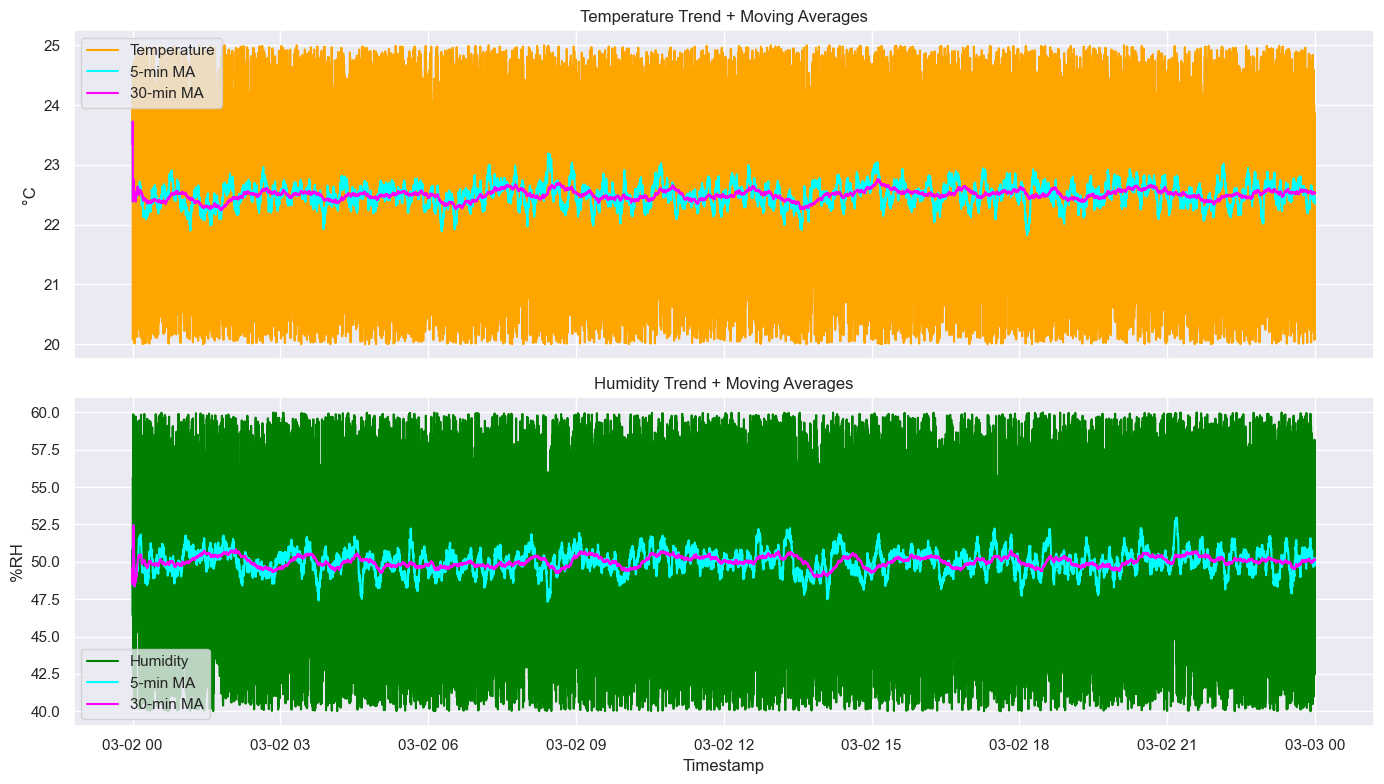

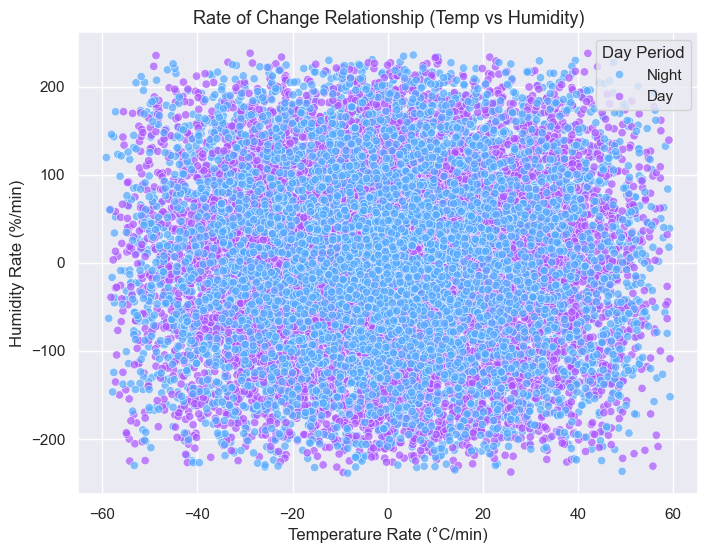

In [2]:
#2.  Feature Engineering
#2.1 Derive features such as rate of change or moving averages of temperature and humidity.


#Feature Extraction + Smoothed Trends (Derive features such as rate of change or moving averages of temperature and humidity)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG: Dark theme
plt.style.use("dark_background")
sns.set_theme(style="darkgrid")

# LOAD DATA 
df = pd.read_csv("sensor_data_2025-03-02.csv")

#  CONVERT timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values("timestamp").reset_index(drop=True)

#  EXTRACT DAY PERIOD 
df["hour"] = df["timestamp"].dt.hour
df["day_period"] = np.where((df["hour"] >= 6) & (df["hour"] < 18), "Day", "Night")

# DEFINE SENSOR COLUMNS 
sensor_cols = ["temperature", "humidity", "light", "pH", "electrical_conductivity"]

#  CLEAN NUMERIC VALUES 
df[sensor_cols] = df[sensor_cols].apply(pd.to_numeric, errors="coerce")

# FEATURE 1: RATE OF CHANGE (DERIVATIVE) 
# Difference per minute
df["temp_rate"] = df["temperature"].diff() / df["timestamp"].diff().dt.total_seconds().div(60)
df["humidity_rate"] = df["humidity"].diff() / df["timestamp"].diff().dt.total_seconds().div(60)

#  FEATURE 2: MOVING AVERAGES 
# Short (5-min) and long (30-min) windows
df.set_index("timestamp", inplace=True)
df["temp_ma_5min"] = df["temperature"].rolling("5min", min_periods=1).mean()
df["temp_ma_30min"] = df["temperature"].rolling("30min", min_periods=1).mean()
df["humidity_ma_5min"] = df["humidity"].rolling("5min", min_periods=1).mean()
df["humidity_ma_30min"] = df["humidity"].rolling("30min", min_periods=1).mean()
df.reset_index(inplace=True)

# FEATURE 3: TEMPERATURE-HUMIDITY INTERACTION 
df["temp_humidity_ratio"] = df["temperature"] / (df["humidity"] + 1e-5)

#  DESCRIPTIVE STATISTICS 
features = ["temperature", "humidity", "temp_rate", "humidity_rate", 
            "temp_ma_5min", "temp_ma_30min", "humidity_ma_5min", 
            "humidity_ma_30min", "temp_humidity_ratio"]

stats = df[features].describe().T
print("\n=== SENSOR FEATURE STATISTICS ===")
print(stats)

# OPTIONAL: Save processed dataset 
df.to_csv("sensor_features.csv", index=False)
print("\nFeature-enhanced dataset saved as 'sensor_features.csv'")

#  VISUALIZE MOVING AVERAGES 
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# TEMPERATURE
sns.lineplot(data=df, x="timestamp", y="temperature", label="Temperature", color="orange", ax=ax[0])
sns.lineplot(data=df, x="timestamp", y="temp_ma_5min", label="5-min MA", color="cyan", ax=ax[0])
sns.lineplot(data=df, x="timestamp", y="temp_ma_30min", label="30-min MA", color="magenta", ax=ax[0])
ax[0].set_title("Temperature Trend + Moving Averages", fontsize=12)
ax[0].set_ylabel("°C")

# HUMIDITY
sns.lineplot(data=df, x="timestamp", y="humidity", label="Humidity", color="green", ax=ax[1])
sns.lineplot(data=df, x="timestamp", y="humidity_ma_5min", label="5-min MA", color="cyan", ax=ax[1])
sns.lineplot(data=df, x="timestamp", y="humidity_ma_30min", label="30-min MA", color="magenta", ax=ax[1])
ax[1].set_title("Humidity Trend + Moving Averages", fontsize=12)
ax[1].set_ylabel("%RH")
ax[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

# RATE OF CHANGE SCATTER PLOT 
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="temp_rate", y="humidity_rate", hue="day_period", palette="cool", alpha=0.7)
plt.title("Rate of Change Relationship (Temp vs Humidity)", fontsize=13)
plt.xlabel("Temperature Rate (°C/min)")
plt.ylabel("Humidity Rate (%/min)")
plt.legend(title="Day Period")
plt.show()



Average Sensor Values by Day/Night:
            temperature  humidity   light
day_period                               
Day               22.49     50.02  777.47
Night             22.50     50.02  325.90


C:\Users\Admin\AppData\Local\Temp\ipykernel_18620\3162883807.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="day_period", y="temperature", palette=["#F39C12", "#5DADE2"])


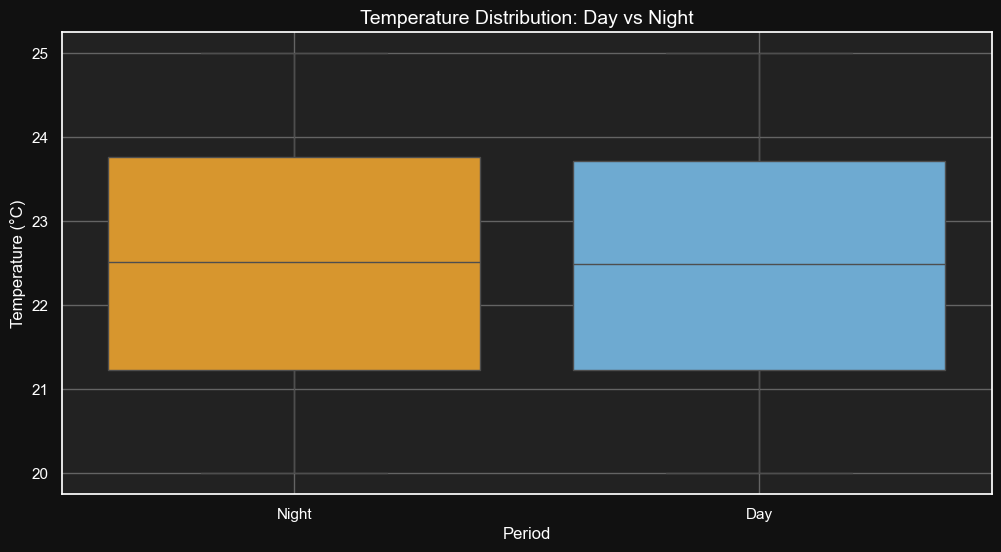

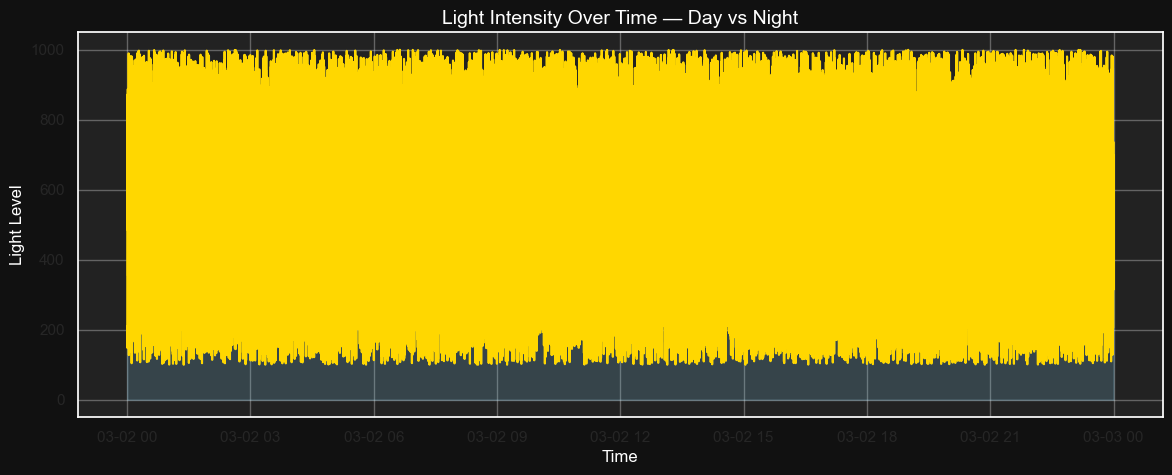

In [3]:
#2.  Feature Engineering
#2.2 Label daytime vs nighttime periods using light intensity.

# Day/Night Labeling + Visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV
df = pd.read_csv("sensor_data_2025-03-02.csv")

# Ensure timestamp column is parsed correctly
df["timestamp"] = pd.to_datetime(df["timestamp"])

# --- Label day vs night based on light intensity ---
# Threshold: adjust based on your sensor scale
light_threshold = df["light"].mean()  # or try df["light"].median()
df["day_period"] = df["light"].apply(lambda x: "Day" if x > light_threshold else "Night")

# --- Compute averages per period ---
avg_stats = df.groupby("day_period")[["temperature", "humidity", "light"]].mean().round(2)
print("\nAverage Sensor Values by Day/Night:")
print(avg_stats)

# --- Visualization ---
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#222", "figure.facecolor": "#111"})
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x="day_period", y="temperature", palette=["#F39C12", "#5DADE2"])
plt.title("Temperature Distribution: Day vs Night", color="white", fontsize=14)
plt.xlabel("Period", color="white")
plt.ylabel("Temperature (°C)", color="white")
plt.xticks(color="white")
plt.yticks(color="white")
plt.grid(True, alpha=0.3)
plt.show()

# --- Optional: Check day-night transition over time ---
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["light"], label="Light Intensity", color="gold")
plt.fill_between(df["timestamp"], df["light"], color="skyblue", alpha=0.2)
plt.title("Light Intensity Over Time — Day vs Night", color="white", fontsize=14)
plt.xlabel("Time", color="white")
plt.ylabel("Light Level", color="white")
plt.grid(alpha=0.3)
plt.show()



 Anomaly Summary:
                    Sensor  Anomaly Count
0              temperature           3869
1                 humidity           3919
2                    light           3857
3                       pH           3761
4  electrical_conductivity           3835


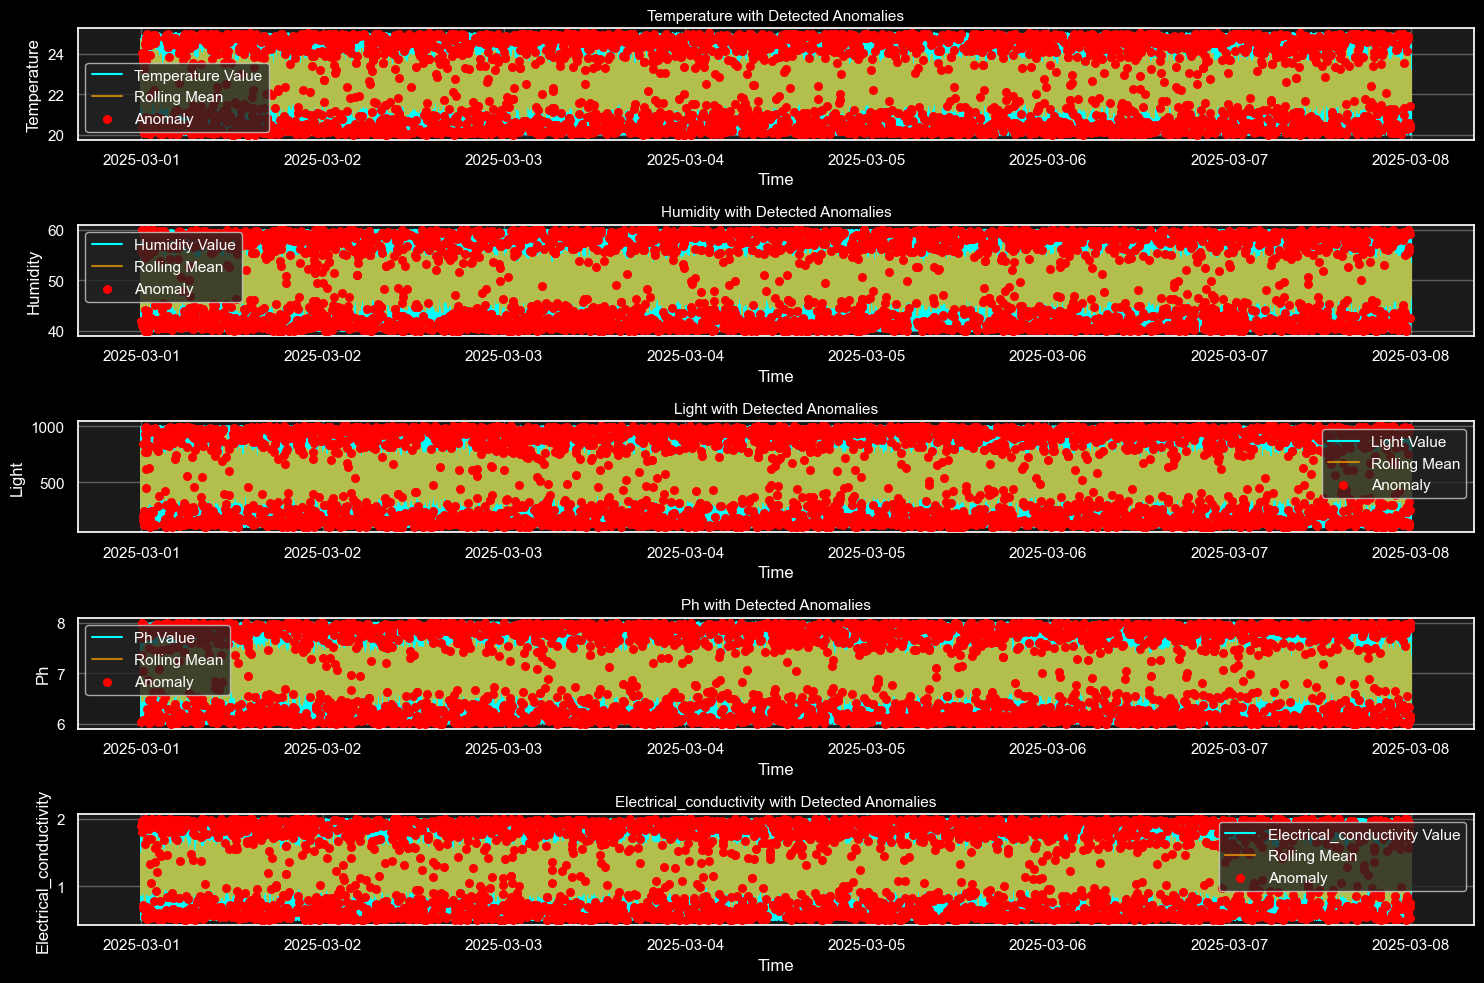

In [10]:
#2. Exploratory Data Analysis (EDA)
#2.1 Anomaly Detection


#Use rolling means and standard deviations to detect abnormal sensor behavior.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess data 
df = pd.read_csv("combined_sensor_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

# Define numeric sensor columns
sensor_cols = ["temperature", "humidity", "light", "pH", "electrical_conductivity"]

#  Compute rolling stats and detect anomalies
window = 10 

# adjust based on sensor frequency (e.g., 10 samples ~ 10 minutes)
threshold = 2  

# standard deviation threshold

for col in sensor_cols:
    df[f"{col}_rolling_mean"] = df[col].rolling(window=window, min_periods=1).mean()
    df[f"{col}_rolling_std"] = df[col].rolling(window=window, min_periods=1).std()
    
    # Detect anomalies: values outside mean ± (threshold × std)
    df[f"{col}_anomaly"] = (
        np.abs(df[col] - df[f"{col}_rolling_mean"]) > threshold * df[f"{col}_rolling_std"]
    )

#  Count anomalies per sensor 
anomaly_summary = df[[f"{c}_anomaly" for c in sensor_cols]].sum().reset_index()
anomaly_summary.columns = ["Sensor", "Anomaly Count"]
anomaly_summary["Sensor"] = anomaly_summary["Sensor"].str.replace("_anomaly", "")

print("\n Anomaly Summary:")
print(anomaly_summary)

#  Visualization: Anomaly plots per sensor 
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1a1a1a", "figure.facecolor": "#000"})
plt.figure(figsize=(15, 10))

for i, col in enumerate(sensor_cols, 1):
    plt.subplot(len(sensor_cols), 1, i)
    plt.plot(df["timestamp"], df[col], label=f"{col.capitalize()} Value", color="cyan")
    plt.plot(df["timestamp"], df[f"{col}_rolling_mean"], label="Rolling Mean", color="orange", alpha=0.7)
    
    # Highlight anomalies
    anomalies = df[df[f"{col}_anomaly"]]
    plt.scatter(anomalies["timestamp"], anomalies[col], color="red", label="Anomaly", s=30, zorder=5)
    
    plt.title(f"{col.capitalize()} with Detected Anomalies", color="white", fontsize=11)
    plt.xlabel("Time", color="white")
    plt.ylabel(col.capitalize(), color="white")
    plt.legend(facecolor="#222", labelcolor="white")
    plt.grid(alpha=0.3)
    plt.xticks(color="white")
    plt.yticks(color="white")

plt.tight_layout()
plt.show()


In [5]:
#2. Feature Engineering
#2.1 Derive features such as rate of change or moving averages of temperature and humidity.
 

# Feature Engineering: Rate of Change + Moving Averages

import pandas as pd
import numpy as np

# Load data 
df = pd.read_csv("sensor_data_2025-03-02.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

# Compute time difference in seconds 
df["time_diff"] = df["timestamp"].diff().dt.total_seconds().fillna(0)

#  Derive rate of change for Temperature and Humidity 
for col in ["temperature", "humidity"]:
    df[f"{col}_diff"] = df[col].diff()             # Absolute difference
    df[f"{col}_rate"] = df[f"{col}_diff"] / df["time_diff"]  # Rate per second
    df[f"{col}_rate"].fillna(0, inplace=True)
    
    #  Rolling moving averages 
    df[f"{col}_MA5"] = df[col].rolling(window=5, min_periods=1).mean()
    df[f"{col}_MA15"] = df[col].rolling(window=15, min_periods=1).mean()
    
    #  Normalized rate (helps compare across different scales) 
    df[f"{col}_norm_rate"] = (df[f"{col}_rate"] - df[f"{col}_rate"].mean()) / df[f"{col}_rate"].std()

#  Drop initial NaNs 
df.fillna(0, inplace=True)

# Display new feature columns 
new_features = [c for c in df.columns if any(x in c for x in ["rate", "MA"])]
print("Derived Features:\n", new_features)
print(df[new_features].head(10))


Derived Features:
 ['temperature_rate', 'temperature_MA5', 'temperature_MA15', 'temperature_norm_rate', 'humidity_rate', 'humidity_MA5', 'humidity_MA15', 'humidity_norm_rate']
   temperature_rate  temperature_MA5  temperature_MA15  temperature_norm_rate  \
0             0.000          23.3300         23.330000               0.000075   
1             0.158          23.7250         23.725000               0.387885   
2            -0.112          23.6700         23.670000              -0.274827   
3            -0.544          22.9625         22.962500              -1.335167   
4            -0.152          22.3860         22.386000              -0.373007   
5             0.780          22.5160         22.651667               1.914577   
6            -0.222          22.2660         22.682857              -0.544821   
7            -0.438          21.6900         22.432500              -1.074991   
8             0.796          22.4540         22.680000               1.953848   
9            -

C:\Users\Admin\AppData\Local\Temp\ipykernel_18620\3627525218.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[f"{col}_rate"].fillna(0, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_18620\3627525218.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

KeyError: 'temperature_MA15'

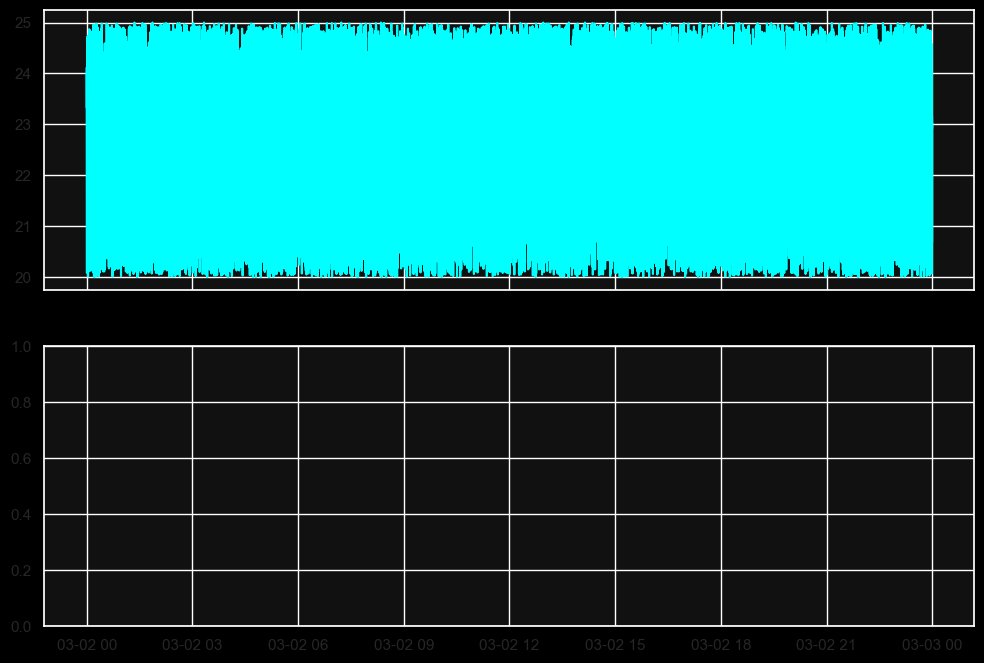

In [6]:
#2. Feature Engineering
#2.2  Label daytime vs nighttime periods using light intensity.


import matplotlib.pyplot as plt
import seaborn as sns

# Load data 
df = pd.read_csv("sensor_data_2025-03-02.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#111", "figure.facecolor": "#000"})

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Temperature trends
ax[0].plot(df["timestamp"], df["temperature"], color="cyan", label="Temperature")
ax[0].plot(df["timestamp"], df["temperature_MA15"], color="orange", label="MA(15)")
ax[0].set_title("Temperature Trend and Moving Average", color="white")
ax[0].legend(facecolor="#222", labelcolor="white")
ax[0].tick_params(colors="white")

# Humidity trends
ax[1].plot(df["timestamp"], df["humidity"], color="magenta", label="Humidity")
ax[1].plot(df["timestamp"], df["humidity_MA15"], color="yellow", label="MA(15)")
ax[1].set_title("Humidity Trend and Moving Average", color="white")
ax[1].legend(facecolor="#222", labelcolor="white")
ax[1].tick_params(colors="white")

plt.tight_layout()
plt.show()


In [7]:
#2. Feature Engineering
#2.2  Label daytime vs nighttime periods using light intensity.


import pandas as pd
import numpy as np

# Load data 
df = pd.read_csv("sensor_data_2025-03-02.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

# Step 1: Compute automatic light threshold 
# Use median as default threshold (can also use df['light'].quantile(0.5))
light_threshold = df["light"].median()

print(f"Using light threshold: {light_threshold:.2f}")

# Step 2: Label periods
df["day_period"] = np.where(df["light"] >= light_threshold, "Day", "Night")

#  Step 3: Optional smoothing (avoid flicker from noise) 
# Smooth using rolling mean before labeling (optional if light sensor is noisy)
df["light_smooth"] = df["light"].rolling(window=3, min_periods=1).mean()
df["day_period_smooth"] = np.where(df["light_smooth"] >= light_threshold, "Day", "Night")

# Step 4: Verify distribution 
print(df["day_period"].value_counts())

# Step 5: Save or display sample 
df[["timestamp", "light", "day_period"]].head(10)


Using light threshold: 545.85
day_period
Night    8640
Day      8640
Name: count, dtype: int64


,timestamp,light,day_period
0,2025-03-02 00:00:00,209.27,Night
1,2025-03-02 00:00:05,148.53,Night
2,2025-03-02 00:00:10,523.69,Night
3,2025-03-02 00:00:15,488.67,Night
4,2025-03-02 00:00:20,588.76,Day
5,2025-03-02 00:00:25,871.73,Day
6,2025-03-02 00:00:30,856.77,Day
7,2025-03-02 00:00:35,789.29,Day
8,2025-03-02 00:00:40,602.68,Day
9,2025-03-02 00:00:45,587.98,Day


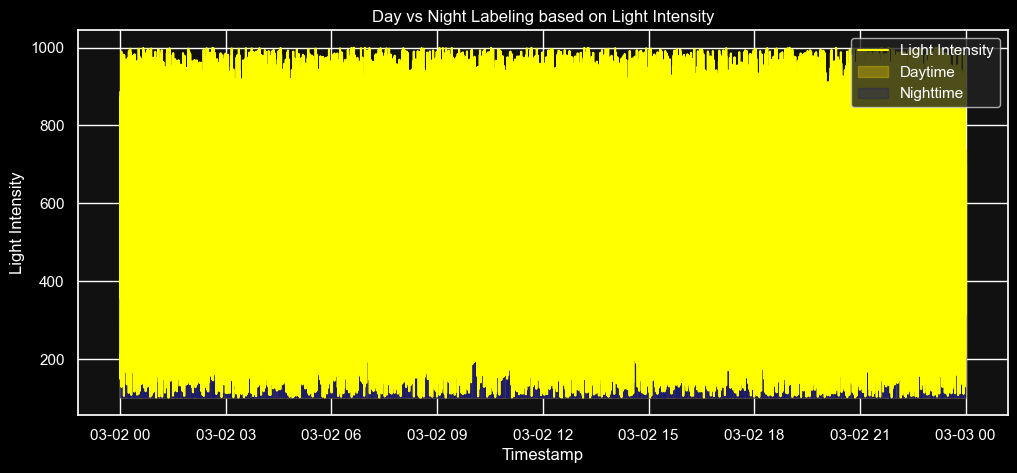

In [8]:
#2. Feature Engineering
#2.2  Label daytime vs nighttime periods using light intensity.


import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#111", "figure.facecolor": "#000"})

plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["light"], color="yellow", label="Light Intensity")
plt.fill_between(df["timestamp"],
                 df["light"].min(),
                 df["light"],
                 where=df["day_period"] == "Day",
                 color="gold",
                 alpha=0.3,
                 label="Daytime")
plt.fill_between(df["timestamp"],
                 df["light"].min(),
                 df["light"],
                 where=df["day_period"] == "Night",
                 color="midnightblue",
                 alpha=0.3,
                 label="Nighttime")

plt.title("Day vs Night Labeling based on Light Intensity", color="white")
plt.xlabel("Timestamp", color="white")
plt.ylabel("Light Intensity", color="white")
plt.legend(facecolor="#222", labelcolor="white")
plt.xticks(color="white")
plt.yticks(color="white")
plt.show()


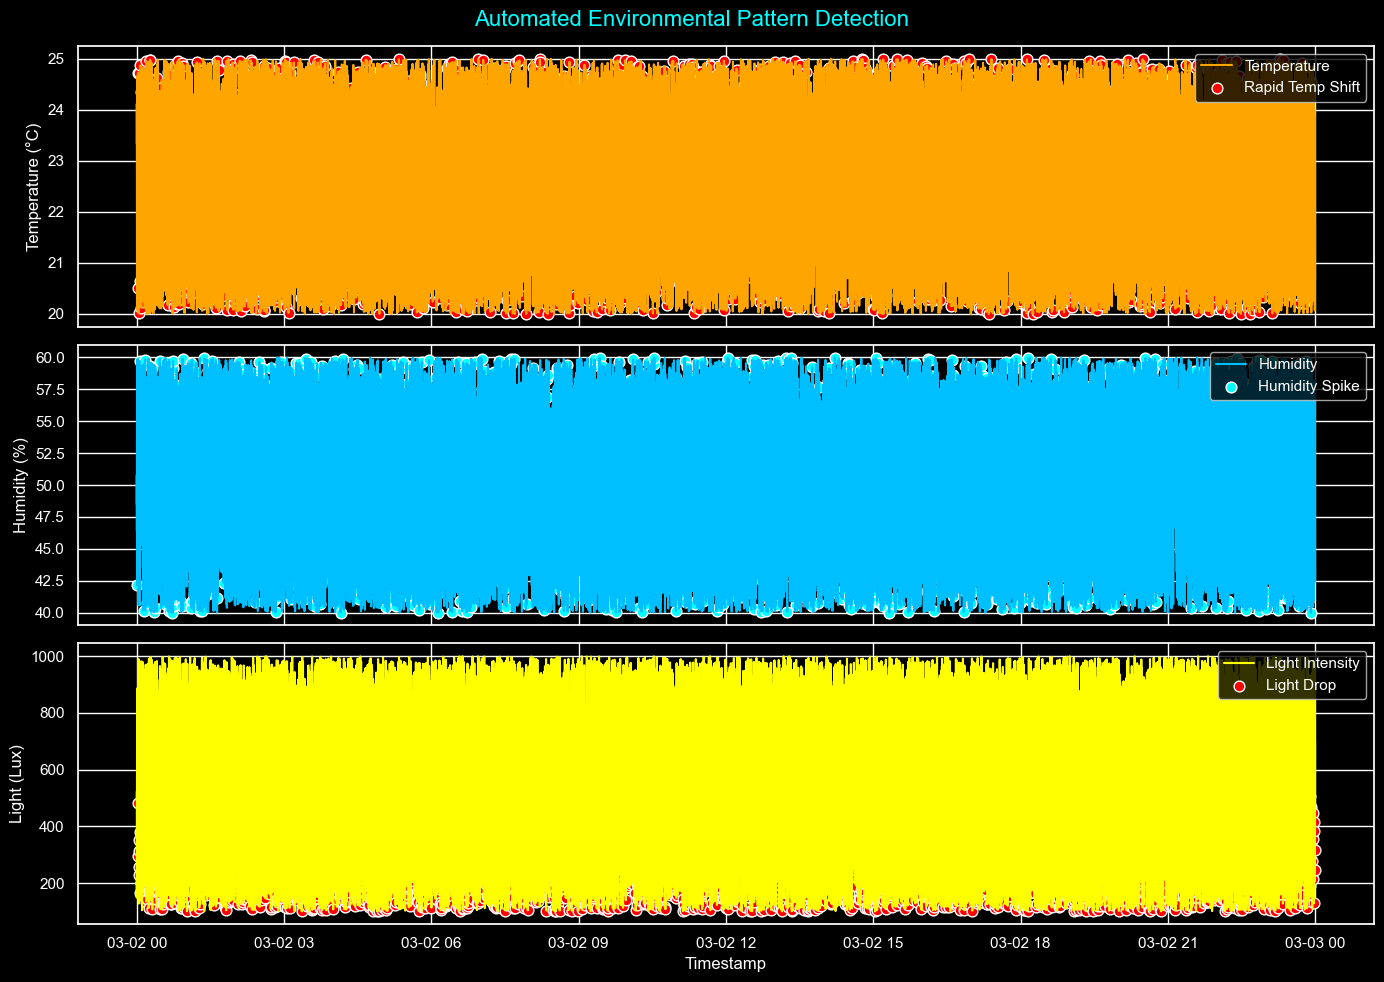


Detected Environmental Events:
          timestamp                    pattern_flag  temperature  humidity  light
2025-03-02 00:01:55                Rapid Temp Shift        24.73     40.60 453.32
2025-03-02 00:02:00                Rapid Temp Shift        20.51     45.13 577.27
2025-03-02 00:02:20                Rapid Temp Shift        20.01     41.23 229.98
2025-03-02 00:02:55                Rapid Temp Shift        24.73     56.71 317.80
2025-03-02 00:04:05                Rapid Temp Shift        24.87     55.13 785.33
2025-03-02 00:04:30                Rapid Temp Shift        20.65     45.22 138.52
2025-03-02 00:05:30                Rapid Temp Shift        20.12     59.27 325.55
2025-03-02 00:05:35                Rapid Temp Shift        24.34     57.03 408.63
2025-03-02 00:09:20                Rapid Temp Shift        20.24     51.03 357.85
2025-03-02 00:11:25                Rapid Temp Shift        24.96     57.26 134.27
2025-03-02 00:13:00 Humidity Spike After Light Drop        23.70  

In [9]:
# Automated Pattern Detection for Environmental Sensors
# (Dark Theme + Matplotlib + Seaborn)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

# Load your sensor data 
df = pd.read_csv("sensor_data_2025-03-02.csv") 

# columns: timestamp, temperature, humidity, light, pH, electrical_conductivity
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

# Label Day/Night based on light intensity 
light_threshold = df["light"].median()
df["day_period"] = np.where(df["light"] > light_threshold, "Day", "Night")

#  Compute Rate of Change (Δ) for Temperature and Humidity 
df["temp_change"] = df["temperature"].diff()
df["humidity_change"] = df["humidity"].diff()
df["light_change"] = df["light"].diff()

# Moving averages for smoothing
df["temp_ma"] = df["temperature"].rolling(window=5, min_periods=1).mean()
df["humidity_ma"] = df["humidity"].rolling(window=5, min_periods=1).mean()

# Detect Rapid Shifts (Temperature / Humidity Spikes) 
temp_thresh = df["temp_change"].std() * 2
humidity_thresh = df["humidity_change"].std() * 2

df["rapid_temp_shift"] = np.abs(df["temp_change"]) > temp_thresh
df["humidity_spike"] = np.abs(df["humidity_change"]) > humidity_thresh

#  Detect Humidity Spikes After Light Drops 
df["light_drop"] = df["light_change"] < -df["light_change"].std()
df["post_lightdrop_humid_spike"] = df["humidity_spike"] & df["light_drop"].shift(1)

# Combine Detected Events
df["pattern_flag"] = np.where(
    df["rapid_temp_shift"], "Rapid Temp Shift",
    np.where(df["post_lightdrop_humid_spike"], "Humidity Spike After Light Drop", None)
)

# Plotting Section (Temperature, Humidity, and Light)
sns.set_palette("magma", 5)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Automated Environmental Pattern Detection", fontsize=16, color="cyan")

# Temperature 
axes[0].plot(df["timestamp"], df["temperature"], color="orange", label="Temperature")
axes[0].scatter(df.loc[df["rapid_temp_shift"], "timestamp"],
                df.loc[df["rapid_temp_shift"], "temperature"],
                color="red", label="Rapid Temp Shift", s=60, edgecolors="white")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend(loc="upper right")

# Humidity 
axes[1].plot(df["timestamp"], df["humidity"], color="deepskyblue", label="Humidity")
axes[1].scatter(df.loc[df["humidity_spike"], "timestamp"],
                df.loc[df["humidity_spike"], "humidity"],
                color="aqua", label="Humidity Spike", s=60, edgecolors="white")
axes[1].set_ylabel("Humidity (%)")
axes[1].legend(loc="upper right")

# Light
axes[2].plot(df["timestamp"], df["light"], color="yellow", label="Light Intensity")
axes[2].scatter(df.loc[df["light_drop"], "timestamp"],
                df.loc[df["light_drop"], "light"],
                color="red", label="Light Drop", s=60, edgecolors="white")
axes[2].set_ylabel("Light (Lux)")
axes[2].legend(loc="upper right")

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

# Print Summary of Detected Patterns 
events = df.dropna(subset=["pattern_flag"])[["timestamp", "pattern_flag", "temperature", "humidity", "light"]]
print("\nDetected Environmental Events:")
print(events.head(15).to_string(index=False))
print(f"\nTotal Detected Events: {len(events)}")
